In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import warnings

if '../' not in sys.path:
    sys.path.append('../')

from functools import partial
    
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp

from mcp_boltzmann import annihilation as ann
from mcp_boltzmann.boltzmann import Boltzmann

warnings.filterwarnings("ignore")

/Users/duncan/src/mcp_boltzmann/notebooks/../mcp_boltzmann/gstar.py:14: RuntimeWarning: overflow encountered in exp
  return u**2*np.sqrt(u**2-z**2)/(np.exp(u) + 1)
/Users/duncan/src/mcp_boltzmann/notebooks/../mcp_boltzmann/gstar.py:17: RuntimeWarning: overflow encountered in exp
  return (u**2 - z**2)**(1.5)/(np.exp(u) + 1)


In [3]:
def load_csv(file_name, skip_header=0):
    plot_data = np.genfromtxt(file_name, delimiter=',', skip_header=skip_header)
    
    x = list(zip(*plot_data))[0]
    y = list(zip(*plot_data))[1]
    
    return x, y

### MCP model parameters

In [4]:
shelton_Q_mass_027 = load_csv('../input/fig/2206.13530_fig3_DNE_027.csv')
shelton_Q_of_M = interp1d(shelton_Q_mass_027[0], shelton_Q_mass_027[1])

In [5]:
MeV = 1
GeV = 1e3

In [6]:
m_mcp = 1.0*MeV

Q = shelton_Q_of_M(1.06)
# Q = 2.7e-9
print(f'{Q=}')

Q=array(8.98845895e-10)


## Annihilation Collision terms

In [7]:
def load_ann_rate(path):
    with np.load(path) as rate_file:
        return interp1d(rate_file['Temp_grid'], rate_file['rate'], bounds_error=False, fill_value=0)

_CF_ff_xx_I = load_ann_rate(f'../output/rates/annihilation/ann_m_{m_mcp}_Q_1.npz')

In [8]:
#total annihilation rate from sm to dark sector
def CF_ann(T, Q):
    return Q**2*_CF_ff_xx_I(T)

def CF_ann_sm_ds(T_sm, T_ds, Q):
    return CF_ann(T_sm, Q) - CF_ann(T_ds, Q)

## Coulomb Scattering

In [9]:
from mcp_boltzmann.elastic_scattering import load_tabulated_rate

mcp_coulomb_rate = load_tabulated_rate(f'../output/rates/coulomb/mcp_coulomb_rate_m_{m_mcp}_Q_1.npz')

In [10]:
def CF_scatt_sm_ds(T_sm, T_ds, Q):
    return Q**2*mcp_coulomb_rate(T_sm, T_ds)

## Plasmon Decay

In [11]:
from mcp_boltzmann import plasma as plas
def CF_plas(T_sm, T_ds, Q):
    return plas.C_plasmon(T_sm, T_ds, m_mcp, Q)

### Z decay

In [12]:
def CF_Z_decay(T_sm, T_ds, Q):
    return plas.C_Z_decay(T_sm, T_ds, m_mcp, Q)

# Setup Boltzmann equation

In [13]:
Boltz = Boltzmann(m_mcp)
Boltz.add_colterm_EM_DS(CF_ann_sm_ds)
Boltz.add_colterm_EM_DS(CF_scatt_sm_ds)
Boltz.add_colterm_EM_DS(CF_plas)
# Boltz.add_colterm_EM_DS(CF_Z_decay)

In [14]:
T_gamma_0 = 1e6 * MeV
T_nu_0 = T_gamma_0
T_DS_0 =  1e-4*T_gamma_0

In [15]:
sol_sm = Boltz.solve_boltzmann_eq_SM(T_gamma_0, T_nu_0)
Boltz.N_eff_SM(sol_sm.y[0][-1], sol_sm.y[1][-1])

2.9642424809589

In [16]:
sol_bsm = Boltz.solve_boltzmann_eq(T_gamma_0, T_nu_0, T_DS_0, Q)

T_gam_final = sol_bsm.y[0][-1]
T_nu_final = sol_bsm.y[1][-1]
T_ds_final = sol_bsm.y[2][-1]

## Neff

In [17]:
from mcp_boltzmann.boltzmann import rho_DS, rho_EM, rho_neutrino

def Delta_Neff_lazy(T_gam, T_ds, m_mcp):
    return (8/7)*(11/4)**(4/3)*(rho_DS(T_ds, m_mcp)/rho_EM(T_gam))

In [18]:
print(Delta_Neff_lazy(T_gam_final, T_ds_final, m_mcp))

[0.03238049]


In [19]:
N_eff_bsm = Boltz.N_eff(sol_bsm.y[0][-1], sol_bsm.y[1][-1], sol_bsm.y[2][-1])
N_eff_sm = Boltz.N_eff_SM(sol_sm.y[0][-1], sol_sm.y[1][-1])
Delta_Neff = N_eff_bsm - N_eff_sm 

In [20]:
print(f'{N_eff_sm=}')
print(f'{N_eff_bsm=}')
print(f'{Delta_Neff=}')

N_eff_sm=2.9642424809589
N_eff_bsm=array([3.01672692])
Delta_Neff=array([0.05248444])


In [21]:
sol_sm.y[1][-1]/sol_sm.y[0][-1]

0.7116294077090303

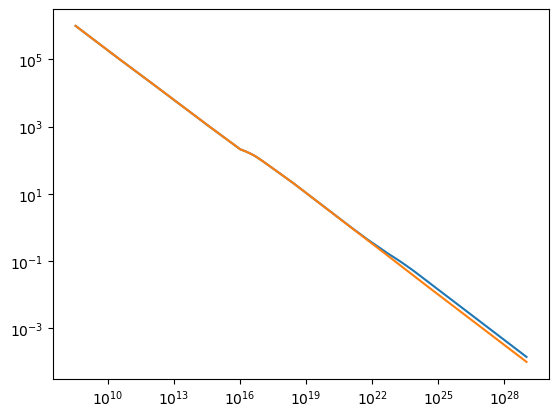

In [22]:
plt.plot(sol_sm.t, sol_sm.y[0])
plt.plot(sol_sm.t, sol_sm.y[1])
plt.yscale('log')
plt.xscale('log')

## Temperature Evolution

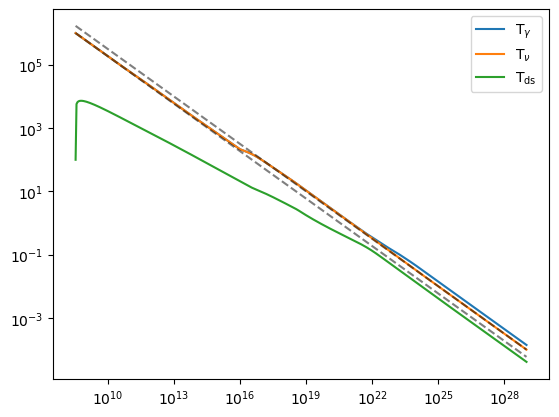

In [23]:
plt.plot(sol_bsm.t, sol_bsm.y[0], label=r'T$_\gamma$')
plt.plot(sol_bsm.t, sol_bsm.y[1], label=r'T$_{\nu}$')
plt.plot(sol_bsm.t, sol_bsm.y[2], label=r'T$_{\rm ds}$')

plt.plot(sol_bsm.t, sol_bsm.y[0][0]*np.sqrt(sol_bsm.t[0]/sol_bsm.t), linestyle='dashed', color='black', alpha=0.5)
plt.plot(sol_bsm.t, sol_bsm.y[1][-1]*np.sqrt(sol_bsm.t[-1]/sol_bsm.t), linestyle='dashed', color='black', alpha=0.5)

plt.yscale('log')
plt.xscale('log')

plt.legend()

plt.show()


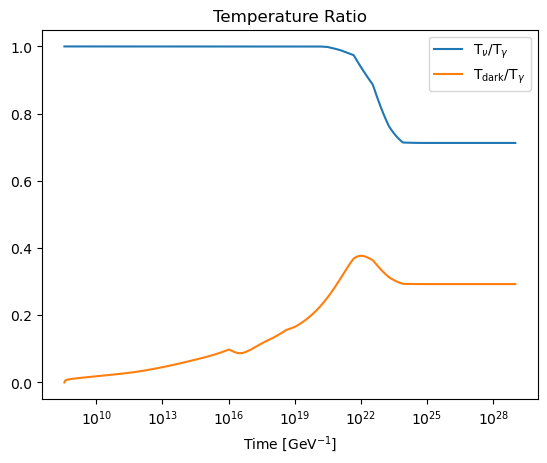

In [24]:
plt.plot(sol_bsm.t, sol_bsm.y[1]/sol_bsm.y[0], label=r'T$_\nu$/T$_\gamma$')
plt.plot(sol_bsm.t, sol_bsm.y[2]/sol_bsm.y[0], label=r'T$_{\rm dark}$/T$_\gamma$')
plt.xscale('log')

plt.xlabel('Time [GeV$^{-1}$]')
plt.title('Temperature Ratio')
plt.legend()

plt.show()

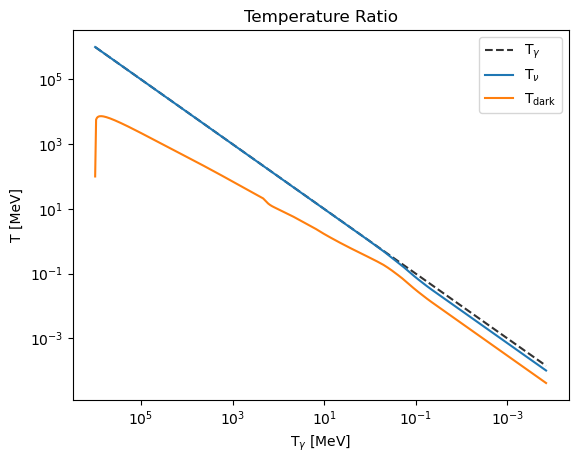

In [25]:
plt.plot(sol_bsm.y[0], sol_bsm.y[0], linestyle='dashed', color='black', alpha=0.8, label=r'T$_\gamma$')
plt.plot(sol_bsm.y[0], sol_bsm.y[1], label=r'T$_\nu$')
plt.plot(sol_bsm.y[0], sol_bsm.y[2], label=r'T$_{\rm dark}$')
plt.yscale('log')
plt.xscale('log')

plt.xlabel(r'T$_{\gamma}$ [MeV]')
plt.ylabel('T [MeV]')
plt.title('Temperature Ratio')
plt.legend()

plt.gca().invert_xaxis()

plt.show()

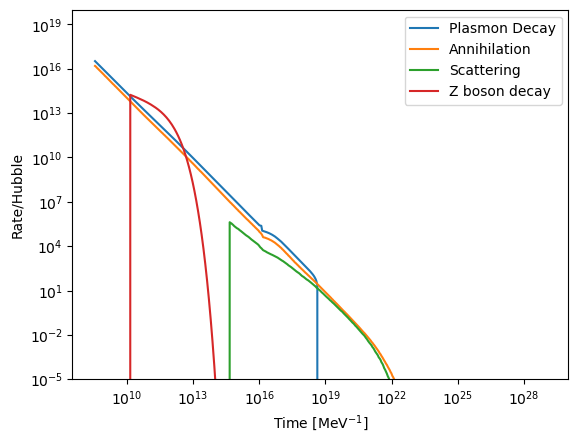

In [26]:
from mcp_boltzmann.boltzmann import Hubble
Hub_plot = Hubble(sol_bsm.y[0], sol_bsm.y[1], sol_bsm.y[2], m_mcp)
plt.plot(sol_bsm.t, np.abs(CF_plas(sol_bsm.y[0], sol_bsm.y[2], Q)/Hub_plot), label='Plasmon Decay')
plt.plot(sol_bsm.t, np.abs(CF_ann_sm_ds(sol_bsm.y[0], sol_bsm.y[2], Q)/Hub_plot), label='Annihilation')
plt.plot(sol_bsm.t, np.abs(CF_scatt_sm_ds(sol_bsm.y[0], sol_bsm.y[2], Q)/Hub_plot), label='Scattering')
plt.plot(sol_bsm.t, np.abs(CF_Z_decay(sol_bsm.y[0], sol_bsm.y[2], Q)/Hub_plot), label='Z boson decay')

plt.legend()
plt.yscale('log')
plt.xscale('log')

plt.ylabel(r'Rate/Hubble')
plt.xlabel(r'Time [MeV$^{-1}$]')

plt.ylim(1e-5, 1e20)

plt.show()

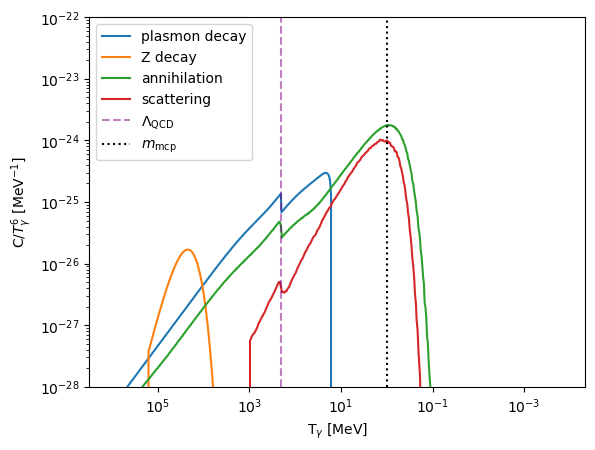

In [27]:
plt.plot(sol_bsm.y[0], CF_plas(sol_bsm.y[0], sol_bsm.y[2], Q)/sol_bsm.y[0]**6, label='plasmon decay')
plt.plot(sol_bsm.y[0], CF_Z_decay(sol_bsm.y[0], sol_bsm.y[2], Q)/sol_bsm.y[0]**6, label='Z decay')
plt.plot(sol_bsm.y[0], CF_ann_sm_ds(sol_bsm.y[0], sol_bsm.y[2], Q)/sol_bsm.y[0]**6, label='annihilation')
plt.plot(sol_bsm.y[0], CF_scatt_sm_ds(sol_bsm.y[0], sol_bsm.y[2], Q)/sol_bsm.y[0]**6, label='scattering')
plt.ylim(1e-28, 1e-22)

plt.axvline(200,  color='purple', linestyle='dashed', alpha=0.5, label=r'$\Lambda_{\rm QCD}$')
plt.axvline(m_mcp, color='black', linestyle='dotted', label=r'$m_{\rm mcp}$')

plt.yscale('log')
plt.xscale('log')

plt.legend(loc='upper left')
plt.gca().invert_xaxis()

plt.xlabel(r'T$_\gamma$ [MeV]')
plt.ylabel(r'C/$T^6_\gamma$ [MeV$^{-1}$]')
plt.show()